# ARIMA Forecast – LastFM Sessions

**Exercise 3 – ML Challenge**

- Data processing: **PySpark**
- Forecasting: **ARIMA(1,1,1)** via statsmodels

## 1. Start Spark session

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .appName('LastFM_ARIMA')
    .config('spark.sql.ansi.enabled', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')

Spark version: 4.1.1


## 2. Load data

In [2]:
DATA_PATH = '../data/userid-timestamp-artid-artname-traid-traname.tsv'

plays = (
    spark.read
    .option('sep', '\t')
    .option('header', 'false')
    .option('mode', 'DROPMALFORMED')
    .csv(DATA_PATH)
    .toDF('user_id', 'timestamp', 'artist_mb_id', 'artist_name', 'track_mb_id', 'track_name')
    .withColumn('timestamp', F.to_timestamp('timestamp'))
    .filter(
        F.col('user_id').isNotNull() &
        F.col('timestamp').isNotNull() &
        F.col('track_name').isNotNull()
    )
    .select('user_id', 'timestamp', 'artist_name', 'track_name')
)

print(f'Total rows: {plays.count():,}')
plays.show(5, truncate=False)

Total rows: 19,150,867
+-----------+-------------------+-----------+------------------------------------------+
|user_id    |timestamp          |artist_name|track_name                                |
+-----------+-------------------+-----------+------------------------------------------+
|user_000001|2009-05-05 01:08:57|Deep Dish  |Fuck Me Im Famous (Pacha Ibiza)-09-28-2007|
|user_000001|2009-05-04 15:54:10|坂本龍一   |Composition 0919 (Live_2009_4_15)         |
|user_000001|2009-05-04 15:52:04|坂本龍一   |Mc2 (Live_2009_4_15)                      |
|user_000001|2009-05-04 15:42:52|坂本龍一   |Hibari (Live_2009_4_15)                   |
|user_000001|2009-05-04 15:42:11|坂本龍一   |Mc1 (Live_2009_4_15)                      |
+-----------+-------------------+-----------+------------------------------------------+
only showing top 5 rows


## 3. Build sessions (gap > 20 min = new session)

In [3]:
w_user = Window.partitionBy('user_id').orderBy('timestamp')

with_sessions = (
    plays
    .withColumn('prev_ts', F.lag('timestamp', 1).over(w_user))
    .withColumn(
        'new_session',
        F.when(
            F.col('prev_ts').isNull() |
            (F.unix_timestamp('timestamp') - F.unix_timestamp('prev_ts') > 20 * 60),
            1
        ).otherwise(0)
    )
    .withColumn('session_id', F.concat_ws('_', F.col('user_id'), F.sum('new_session').over(w_user)))
    .drop('prev_ts', 'new_session')
)

print(f'Total sessions: {with_sessions.select("session_id").distinct().count():,}')

Total sessions: 1,041,883


## 4. Top 10 songs in the top 50 longest sessions by track count

In [4]:
top50 = (
    with_sessions
    .groupBy('session_id')
    .count()
    .orderBy(F.desc('count'))
    .limit(50)
    .select('session_id')
)

top10 = (
    with_sessions
    .join(F.broadcast(top50), 'session_id')
    .groupBy('artist_name', 'track_name')
    .count()
    .orderBy(F.desc('count'))
    .limit(10)
)

print('Top 10 songs in top 50 longest sessions:')
top10.show(truncate=False)

Top 10 songs in top 50 longest sessions:


+-------------------------+-------------------------------------+-----+
|artist_name              |track_name                           |count|
+-------------------------+-------------------------------------+-----+
|Cake                     |Jolene                               |1214 |
|The Knife                |Heartbeats                           |868  |
|Jeff Buckley & Gary Lucas|How Long Will It Take                |726  |
|Broken Social Scene      |Anthems For A Seventeen Year Old Girl|659  |
|Elliott Smith            |St. Ides Heaven                      |646  |
|The Killers              |Bonus Track                          |634  |
|2Pac                     |Starin' Through My Rear View         |617  |
|The Rolling Stones       |Beast Of Burden                      |613  |
|Everclear                |The Swing                            |604  |
|Kanye West               |See You In My Nightmares             |536  |
+-------------------------+-------------------------------------

## 5. Top 1 user by number of sessions

In [5]:
top_user_row = (
    with_sessions
    .select('user_id', 'session_id').distinct()
    .groupBy('user_id')
    .count()
    .orderBy(F.desc('count'))
    .first()
)

top_user   = top_user_row['user_id']
top_n_sess = top_user_row['count']
print(f'Top user: {top_user}  -  {top_n_sess:,} sessions')

Top user: user_000833  -  6,897 sessions


## 6. Weekly session count for the top user

In [6]:
weekly_spark = (
    with_sessions
    .filter(F.col('user_id') == top_user)
    .groupBy('session_id')
    .agg(F.min('timestamp').alias('session_start'))
    .withColumn('week', F.date_trunc('week', 'session_start'))
    .groupBy('week')
    .agg(F.count('session_id').alias('n_sessions'))
    .orderBy('week')
)

weekly_spark.show(10)

+-------------------+----------+
|               week|n_sessions|
+-------------------+----------+
|2005-02-14 00:00:00|         1|
|2005-02-21 00:00:00|        14|
|2005-02-28 00:00:00|        10|
|2005-03-07 00:00:00|        10|
|2005-03-14 00:00:00|        11|
|2005-03-21 00:00:00|         9|
|2005-03-28 00:00:00|        14|
|2005-04-04 00:00:00|        19|
|2005-04-11 00:00:00|        13|
|2005-04-18 00:00:00|        15|
+-------------------+----------+
only showing top 10 rows


## 7. Convert to pandas and plot

Date range: 2005-02-14 to 2009-05-18
Weeks with data: 221


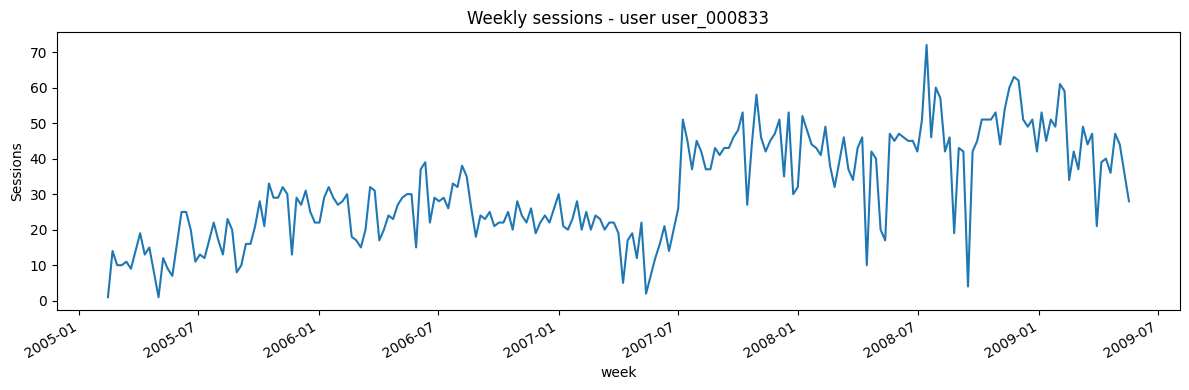

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

weekly_pd = weekly_spark.toPandas()
weekly_pd['week'] = pd.to_datetime(weekly_pd['week']).dt.tz_localize(None)
weekly = weekly_pd.set_index('week')['n_sessions'].sort_index()

print(f'Date range: {weekly.index.min().date()} to {weekly.index.max().date()}')
print(f'Weeks with data: {len(weekly)}')

weekly.plot(title=f'Weekly sessions - user {top_user}', figsize=(12, 4))
plt.ylabel('Sessions')
plt.tight_layout()
plt.show()


## 8. ARIMA(1,1,1) forecast - next 3 months (~13 weeks)

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

model  = ARIMA(weekly.fillna(0), order=(1, 1, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             n_sessions   No. Observations:                  221
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -786.586
Date:                Thu, 02 Apr 2026   AIC                           1579.172
Time:                        14:49:14   BIC                           1589.352
Sample:                             0   HQIC                          1583.283
                                - 221                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1186      0.100      1.181      0.238      -0.078       0.315
ma.L1         -0.7326      0.072    -10.240      0.000      -0.873      -0.592
sigma2        74.4531      4.598     16.194      0.0

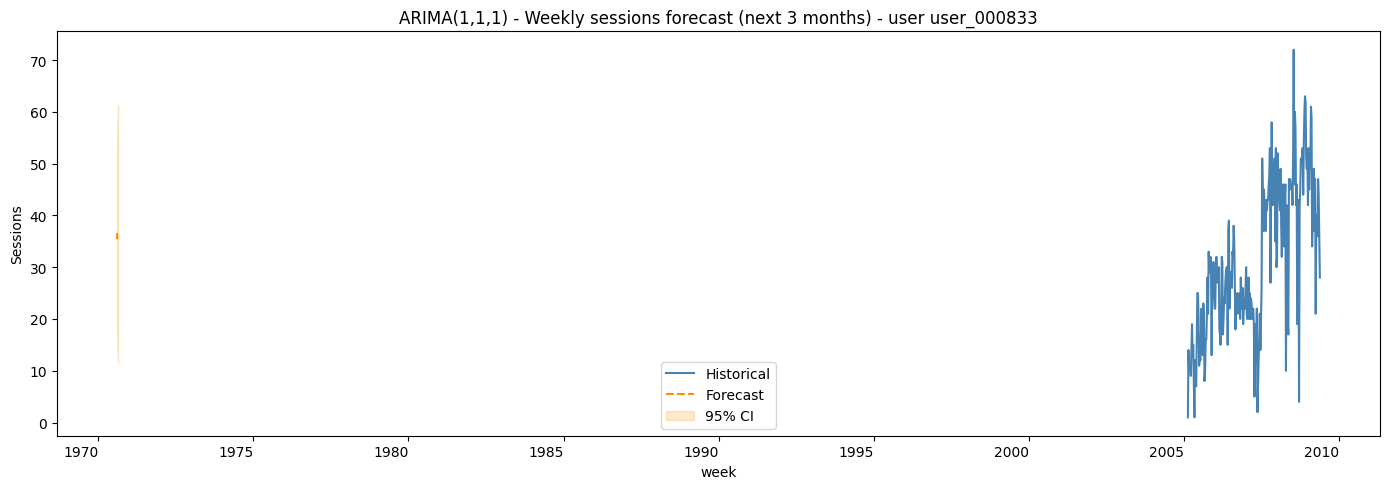

Forecast values:


,predicted_sessions,lower n_sessions,upper n_sessions
221,35.43,18.52,52.34
222,36.31,18.18,54.44
223,36.41,17.53,55.30
224,36.42,16.85,56.00
225,36.43,16.19,56.66
226,36.43,15.55,57.30
227,36.43,14.93,57.93
228,36.43,14.32,58.53
229,36.43,13.74,59.12
230,36.43,13.16,59.69


In [12]:
FORECAST_WEEKS = 13

forecast = result.get_forecast(steps=FORECAST_WEEKS)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
weekly.plot(ax=ax, label='Historical', color='steelblue')
fc_mean.plot(ax=ax, label='Forecast', color='darkorange', linestyle='--')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color='darkorange', alpha=0.2, label='95% CI')
ax.set_title(f'ARIMA(1,1,1) - Weekly sessions forecast (next 3 months) - user {top_user}')
ax.set_ylabel('Sessions')
ax.legend()
plt.tight_layout()
plt.show()

print('Forecast values:')
fc_mean.rename('predicted_sessions').to_frame().join(fc_ci).round(2)

In [13]:
spark.stop()